In [106]:
import pybamm 
import numpy as np
import matplotlib.pyplot as plt

In [107]:
# Select some standard parameter values
parameter_values = pybamm.ParameterValues("Marquis2019")

In [108]:
# Search for the negative particle diffusivity
parameter_values.search("Negative particle diffusivity [m2.s-1]")

Negative particle diffusivity [m2.s-1]	<function graphite_mcmb2528_diffusivity_Dualfoil1998 at 0x2a0bb71c0>


In [109]:
# Set the standard diffusivity as the in our parameter_value set
standard_diffusivity_function = parameter_values["Negative particle diffusivity [m2.s-1]"]


In [110]:
# Define an alternative diffusivity fucntion using pybamm syntax
def custom_diffusivity(c_e, T):
    """
    Custom particle diffusivity function using PyBaMM symbolic operators.
    """
    D_0 = pybamm.Scalar(2e-14)  # Base diffusivity
    decay_rate = pybamm.Scalar(5e-5)  # Decay rate
    return D_0 * pybamm.exp(-decay_rate * c_e)

custom_diffusivity(1000, 20)


Scalar(0x6ce7814bdcc76cf4, 1.902458849001428e-14, children=[], domains={})

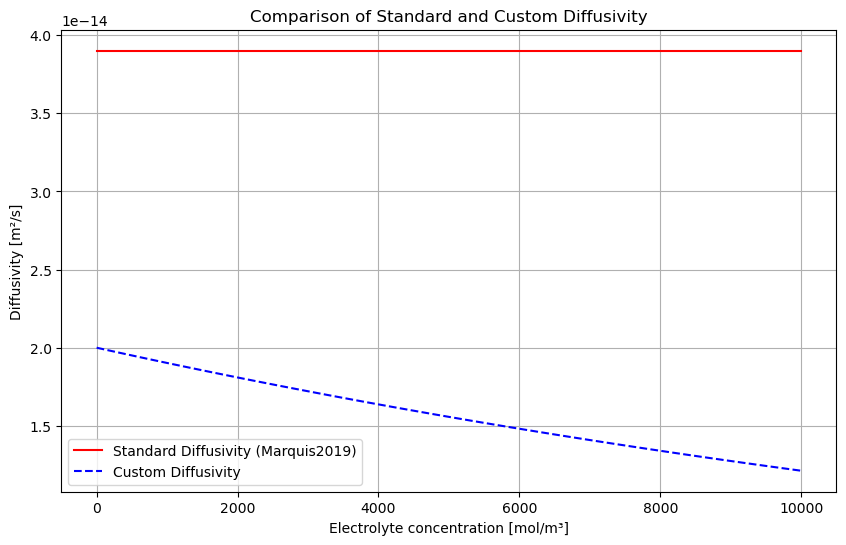

In [111]:
# Compare the two fucntions 


# Define range for concentration and fixed temperature
c_e_range = np.linspace(0, 10000, 100)  # Concentration [mol/m³]
T_fixed = pybamm.Scalar(298.15)  # Fixed temperature [K]

# Evaluate diffusivity for the custom function
custom_diffusivity_values = [
    custom_diffusivity(pybamm.Scalar(c_e), T_fixed).evaluate() for c_e in c_e_range
]

# Evaluate diffusivity for the standard function
standard_diffusivity_values = [
    standard_diffusivity_function(pybamm.Scalar(c_e), T_fixed).evaluate() for c_e in c_e_range
]

# Plot both curves
plt.figure(figsize=(10, 6))
plt.plot(c_e_range, standard_diffusivity_values, label="Standard Diffusivity (Marquis2019)", color="red")
plt.plot(c_e_range, custom_diffusivity_values, label="Custom Diffusivity", color="blue", linestyle="--")
plt.xlabel("Electrolyte concentration [mol/m³]")
plt.ylabel("Diffusivity [m²/s]")
plt.title("Comparison of Standard and Custom Diffusivity")
plt.legend()
plt.grid()
plt.show()


In [112]:
# Standard parameter values
standard_params = pybamm.ParameterValues("Chen2020")

# Custom parameter values
custom_params = pybamm.ParameterValues("Chen2020")
custom_params.update({"Negative particle diffusivity [m2.s-1]": custom_diffusivity})


In [113]:
# Check we have updated them correctly
print(custom_params["Negative particle diffusivity [m2.s-1]"])


<function custom_diffusivity at 0x2a9aa5b40>


In [114]:
# Define a simple charge-discharge experiment
experiment = pybamm.Experiment(
    ["Discharge at 1 C until 2.5 V",
        "Hold at 2.5 V until C/50" ,
       "Charge at 1 C until 4.0 V" ]
)

# Create simulations using DFN model
model = pybamm.lithium_ion.DFN()



# Simulation with standard parameters
sim_standard = pybamm.Simulation(model, parameter_values=standard_params, experiment=experiment)
solution_standard = sim_standard.solve()

# Simulation with custom parameters
sim_custom = pybamm.Simulation(model, parameter_values=custom_params, experiment=experiment)
solution_custom = sim_custom.solve()

# Combine simulations for plotting
sims = [sim_standard,sim_custom]




At t = 472.93 and h = 2.58643e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 232.93 and h = 3.87386e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 427.36 and h = 2.46682e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 187.36 and h = 1.14458e-13, the corrector convergence failed repeatedly or with |h| = hmin.


In [115]:
#One way to plot and compare 
pybamm.dynamic_plot(sims)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.689874948150286, step=0.01689874948150286)…